**Overview**  
This notebook describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - calculate the most important metrics;
    - plot ROC-AUC curve
2. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in XGBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Creare dataframe with the main indiators of models' performance


In [82]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict, cross_validate, StratifiedGroupKFold, GridSearchCV, GroupShuffleSplit, cross_val_score, GroupKFold
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, roc_curve, recall_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

First, let's import datasets and y-target, created earlier:

In [276]:
with open('X_padel.pickle', 'rb') as input:
    X_padel = pickle.load(input)

In [278]:
with open('X_standard.pickle', 'rb') as input:
    X_standard = pickle.load(input)

In [279]:
with open('viscosity.pickle', 'rb') as input:
    target = pickle.load(input)
target = np.log10(target)

In [280]:
with open('X_standard.pickle', 'rb') as input:
    X_standard_pca = pickle.load(input)

In [284]:
with open('X_padel.pickle', 'rb') as input:
    X_padel_pca = pickle.load(input)

In [285]:
with open('groups.pickle', 'rb') as input:
    groups = pickle.load(input)

To facilitate automatic calculation of metrics and asiggning labels, we weill create dictionaries with imported descriptors datasets (standard datasets and datasetes with reduced dimensionality)

In [287]:
descriptors_dict = {'Standard':X_standard, 'Padel':X_padel}

In [289]:
descriptors_dict_pca = {'Standard':X_standard, 'Padel':X_padel}

In [416]:
scores = {'Descriptors':[], 'Estimator':[], 'Full or PCA':[], 'RMSE_CV':[], 'Stddev_RMSE_CV':[], 'R2_CV':[], 'MAE_CV':[],  'RMSE_test':[], 'MAE_test':[], 'R2_test':[] }

The function below performs multiple tasks:
1. First, it create matplotlib figure object and axes with two fields,
2. Then for each of two datasets in descriptors dictionary (standard and PCA), we:
    - Create a pipeline, made of MinMaxScaler and algorithm,
    - Split dataset into training and testing subsets;
    - Then we search for optimal parameters with functions from [hyperopt package](http://hyperopt.github.io/hyperopt/);
    - Then we extract the best model and train it with X_train and y_train;
    - Then we claculate different metrics (Accuracy, F1-Score, ROC_AUC score) and append it to the special dictionary with results, as well as some information abour descriptors sets and name of studied algorithm
    - Finally, we plot ROC-AUC curve 

In [424]:
def calculate_to_score(pipe, estimator_name, param_grid, descriptors_dict = descriptors_dict, target=target, type = 'Full', groups = groups):
    fig, axes = plt.subplots(1, 2, figsize = (26,12))
    i = 0
    
    scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}
    for key, value in descriptors_dict.items():
        splitter = GroupShuffleSplit(n_splits=2, random_state = 0)
        split = splitter.split(X = value, y = target, groups = groups)
        train_indices, test_indices = next(split)
        X_train, y_train, groups_train = value.iloc[train_indices], target.iloc[train_indices], groups[train_indices]
        X_test, y_test, groups_test = value.iloc[test_indices], target.iloc[test_indices], groups[test_indices]       
        cv = GroupKFold(n_splits = 10)
        def objective(params, X, target, groups_train):
            #pipe = make_pipeline(MinMaxScaler(), estimator)
            pipe.set_params(**params)
            scores = cross_validate(pipe, X, target, cv = cv, groups = groups_train, scoring = scoring)
            rmse_cv = -scores['test_rmse']
            stddev_cv = rmse_cv.std()
            mae_cv = -scores['test_mae'].mean()
            r2_cv = scores['test_r2'].mean()
            return {'loss':rmse_cv.mean(), 'stddev':stddev_cv,  'status':STATUS_OK, 'Trained_model':pipe, 'R2_CV':r2_cv, 'MAE_CV':mae_cv}
            
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train, groups_train = groups_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  50)
        print(best)
        best_model_and_properties = get_best_model_from_trials(trials)

        
        print('Loss is {}'.format(best_model_and_properties[2]))
        print('Standard deviation is {}'.format(best_model_and_properties[1]))
        best_estimator  = best_model_and_properties[0]
        
        scores['RMSE_CV'].append(best_model_and_properties[2])
        scores['Stddev_RMSE_CV'].append(best_model_and_properties[1])
        scores['R2_CV'].append(best_model_and_properties[3])
        scores['MAE_CV'].append(best_model_and_properties[4])
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)

        
        scores['RMSE_test'].append(root_mean_squared_error(y_test, predictions))
        scores['MAE_test'].append(mean_absolute_error(y_test, predictions))
        scores['R2_test'].append(r2_score(y_test, predictions))
        scores['Full or PCA'].append(type)
        scores['Estimator'].append(estimator_name)
       
        axes[i].scatter(y_test, predictions)
        axes[i].set_xlim(np.min(y_test), np.max(y_test))
        axes[i].set_ylim(np.min(y_test), np.max(y_test))
        axes[i].plot([np.min(y_test),np.max(y_test)],[np.min(y_test),np.max(y_test)], 'k--')
        axes[i].set_title('Parity plot for {} descriptors'.format(key))
        axes[i].set_xlabel('Test values')
        axes[i].set_ylabel('Predicted values')
        scores['Descriptors'].append(key)
        i += 1
    plt.tight_layout()
    plt.savefig('Parity_plots_structure/'+estimator_name+'_'+type+'.png')

Subfunction below is to retrieve best model from Trials object ans is used in main functions

In [426]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return (best_trial_obj['result']['Trained_model'], best_trial_obj['result']['stddev'], best_trial_obj['result']['loss'], 
            best_trial_obj['result']['R2_CV'],  best_trial_obj['result']['MAE_CV'])

Let's initialize scores dictionary and test function with Logistic Regression

In [428]:
pipe = Pipeline([('var_sel', VarianceThreshold(threshold=0.1)), ('scaler', StandardScaler()), 
                 ('lasso',Lasso(max_iter=15000))])

In [430]:
param_grid = {'var_sel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4), 
             'lasso__alpha':hp.loguniform(label = 'alpha', low = -2, high  = 2)}

100%|██████████| 50/50 [00:57<00:00,  1.16s/trial, best loss: 1.5111172269638282]
{'alpha': 0.14447997761427459, 'threshold': 0.12881170795923177}
Loss is 1.5111172269638282
Standard deviation is 0.22572365570177738
100%|██████████| 50/50 [00:54<00:00,  1.08s/trial, best loss: 1.5201384643210627]
{'alpha': 0.15673660557066896, 'threshold': 0.04597962436110428}
Loss is 1.5201384643210627
Standard deviation is 0.22896161101099435


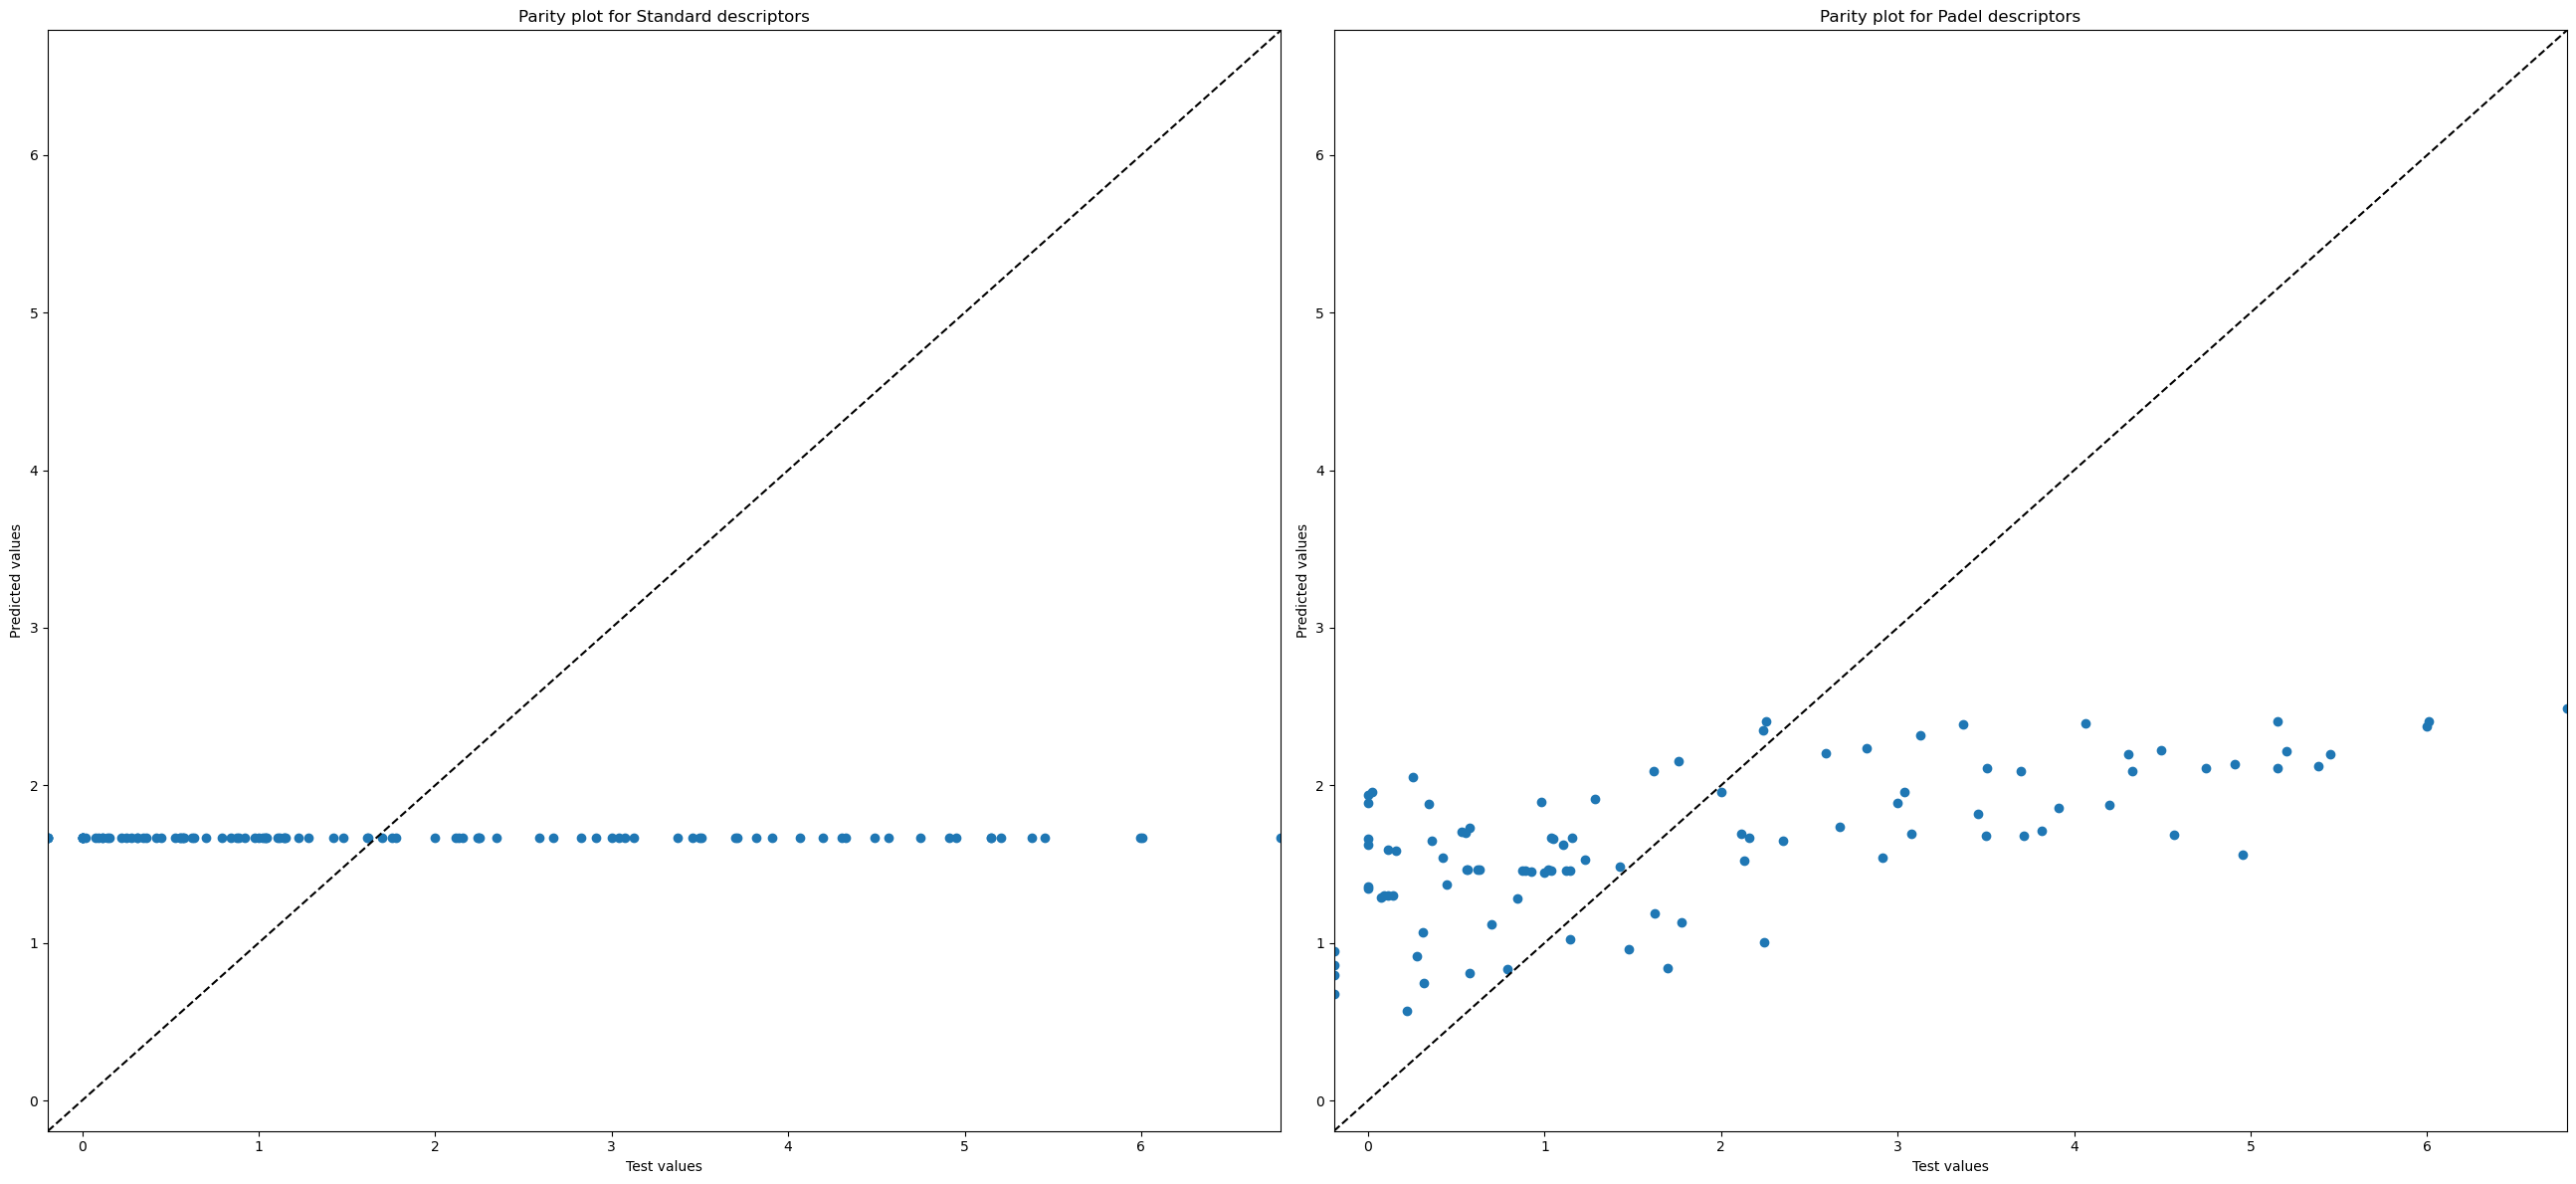

In [432]:
calculate_to_score(pipe, estimator_name='Lasso regression', 
                   param_grid = param_grid)

100%|██████████| 50/50 [00:54<00:00,  1.09s/trial, best loss: 1.48475648880398]  
{'alpha': 0.13871615247210264, 'threshold': 0.0015201780301568896}
Loss is 1.48475648880398
Standard deviation is 0.2098966369516402
100%|██████████| 50/50 [00:54<00:00,  1.09s/trial, best loss: 1.5087735780201066]
{'alpha': 0.13539897410002286, 'threshold': 0.057576253770365765}
Loss is 1.5087735780201066
Standard deviation is 0.22764233359508712


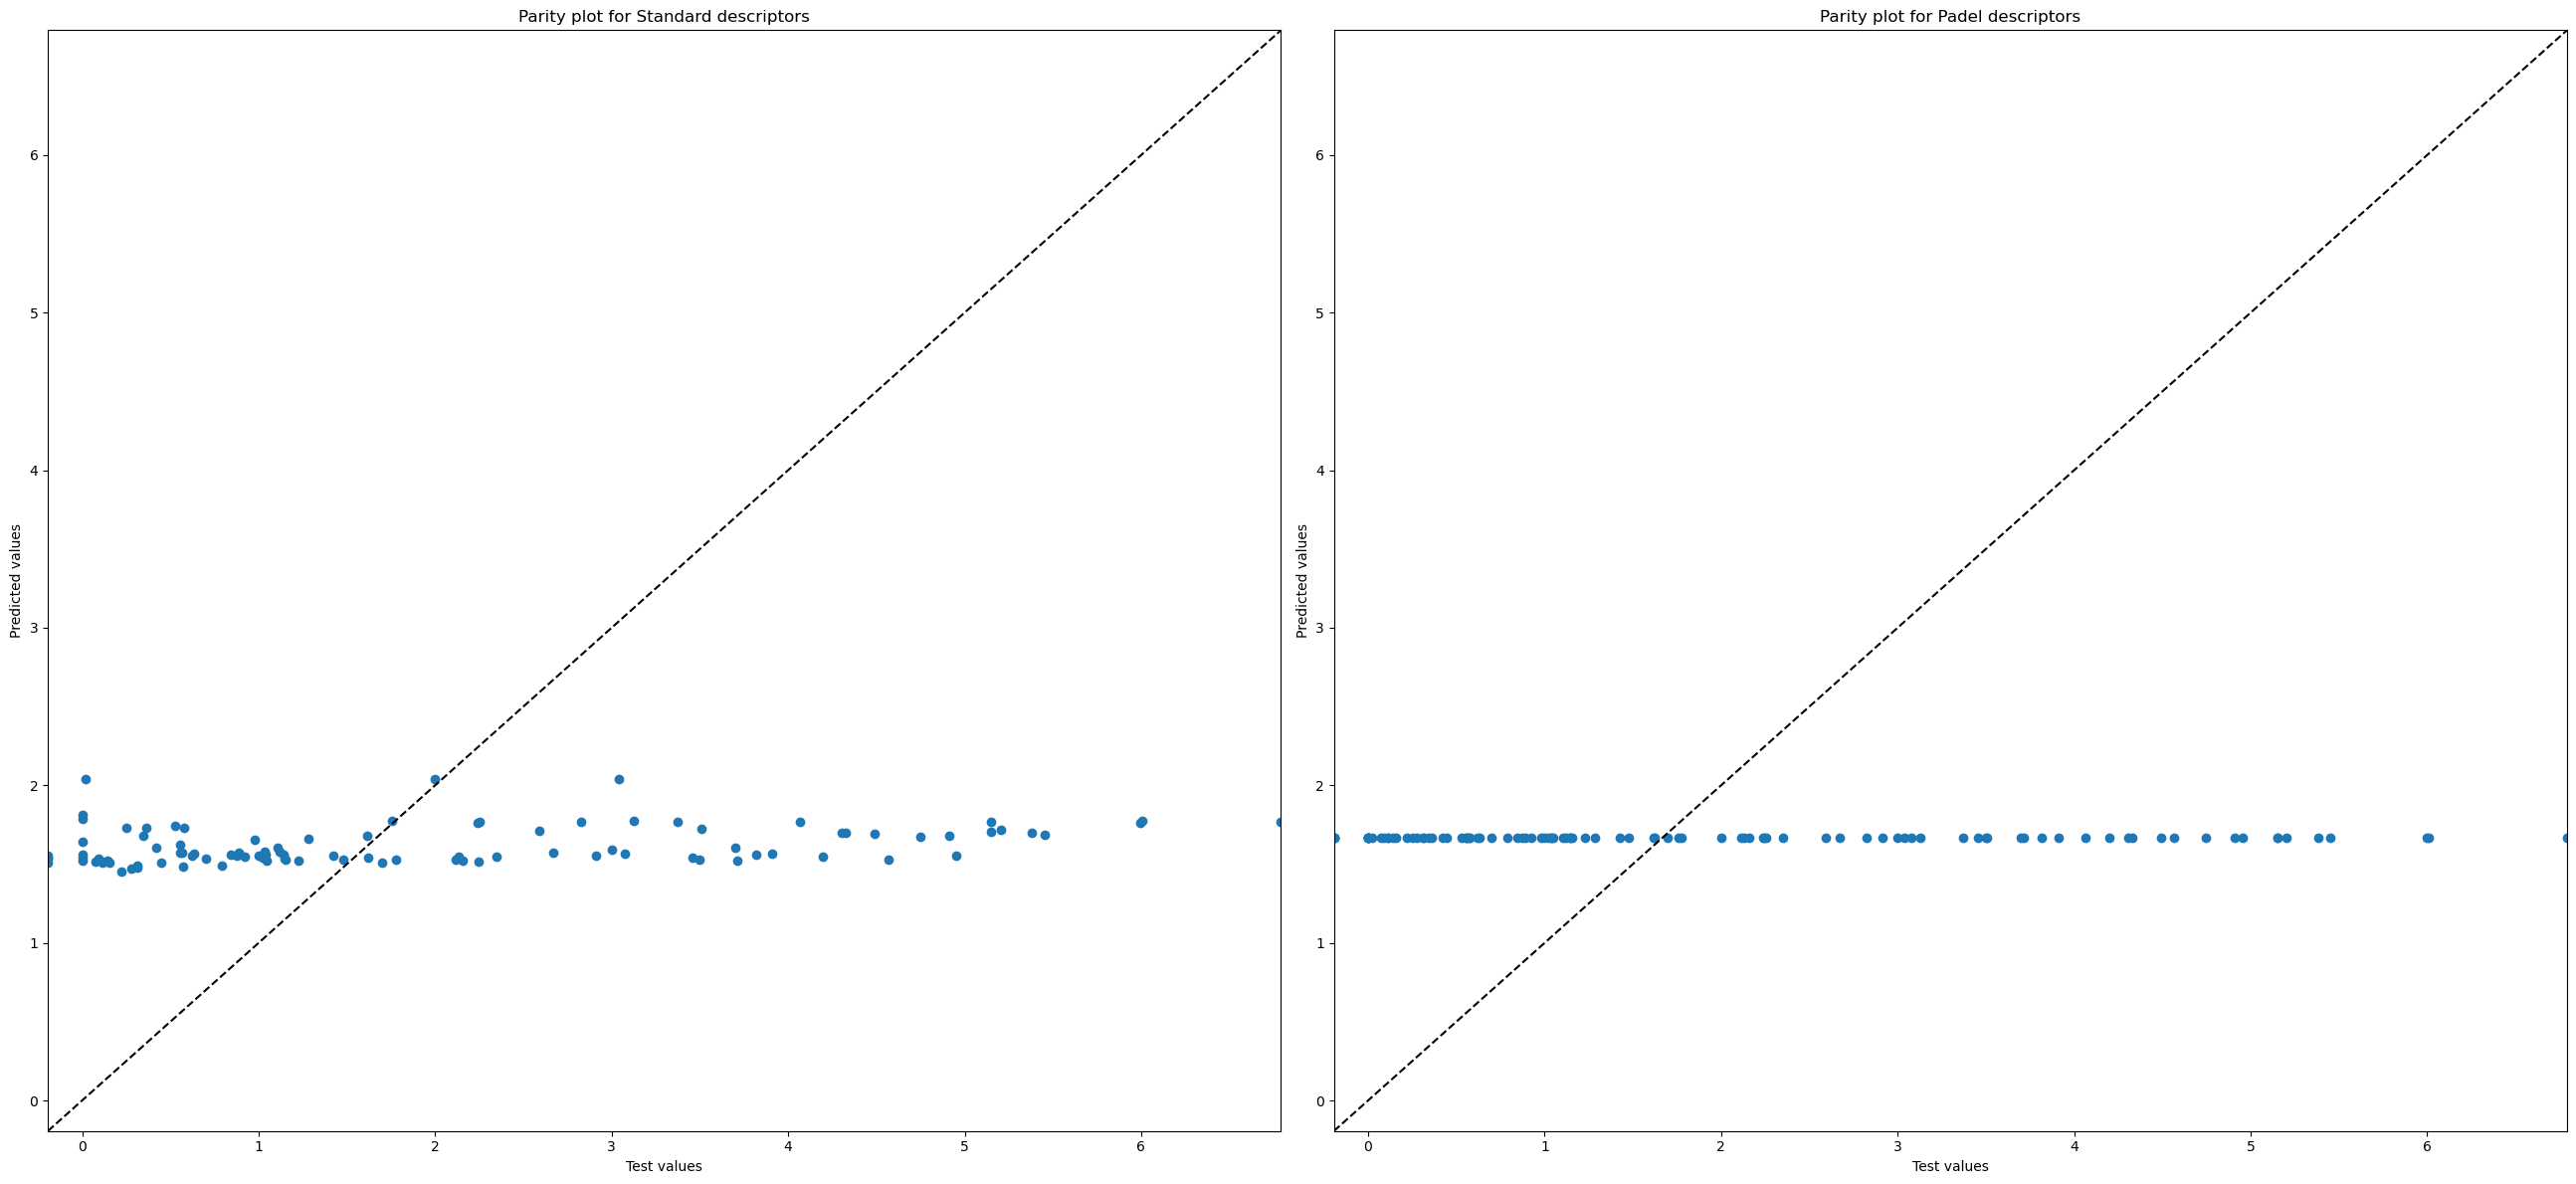

In [433]:
calculate_to_score(pipe, estimator_name='Lasso Regression', 
                   param_grid = param_grid,
                  descriptors_dict=descriptors_dict_pca, type = 'PCA')

Let's continue with other models. The first one will be
**Random Forest Classification**

In [434]:
pipe = Pipeline([('varsel', VarianceThreshold()),('randomforest', RandomForestRegressor(n_jobs = -1))])

In [435]:
space={'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
    'randomforest__max_depth':hp.randint('max_depth',1,25),  'randomforest__max_features':hp.choice('max_features', [None, 'sqrt', 'log2']),
       'randomforest__min_samples_split':hp.randint('min_samples_split', 2, 8),
       'randomforest__min_samples_leaf': hp.randint('min_samples_leaf', 2, 10),
      'randomforest__n_estimators':hp.randint('n_estimators',10, 150),
      'randomforest__criterion': hp.choice('criterion', ["squared_error", "absolute_error", "friedman_mse"])}

100%|██████████| 50/50 [08:36<00:00, 10.33s/trial, best loss: 1.2294054282047073]
{'criterion': 0, 'max_depth': 11, 'max_features': 0, 'min_samples_leaf': 7, 'min_samples_split': 6, 'n_estimators': 22, 'threshold': 0.37974501861704707}
Loss is 1.2294054282047073
Standard deviation is 0.23098472869379993
100%|██████████| 50/50 [16:08<00:00, 19.37s/trial, best loss: 1.1782502805657808]
{'criterion': 0, 'max_depth': 23, 'max_features': 0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 111, 'threshold': 0.23771875000284992}
Loss is 1.1782502805657808
Standard deviation is 0.2131817301968142


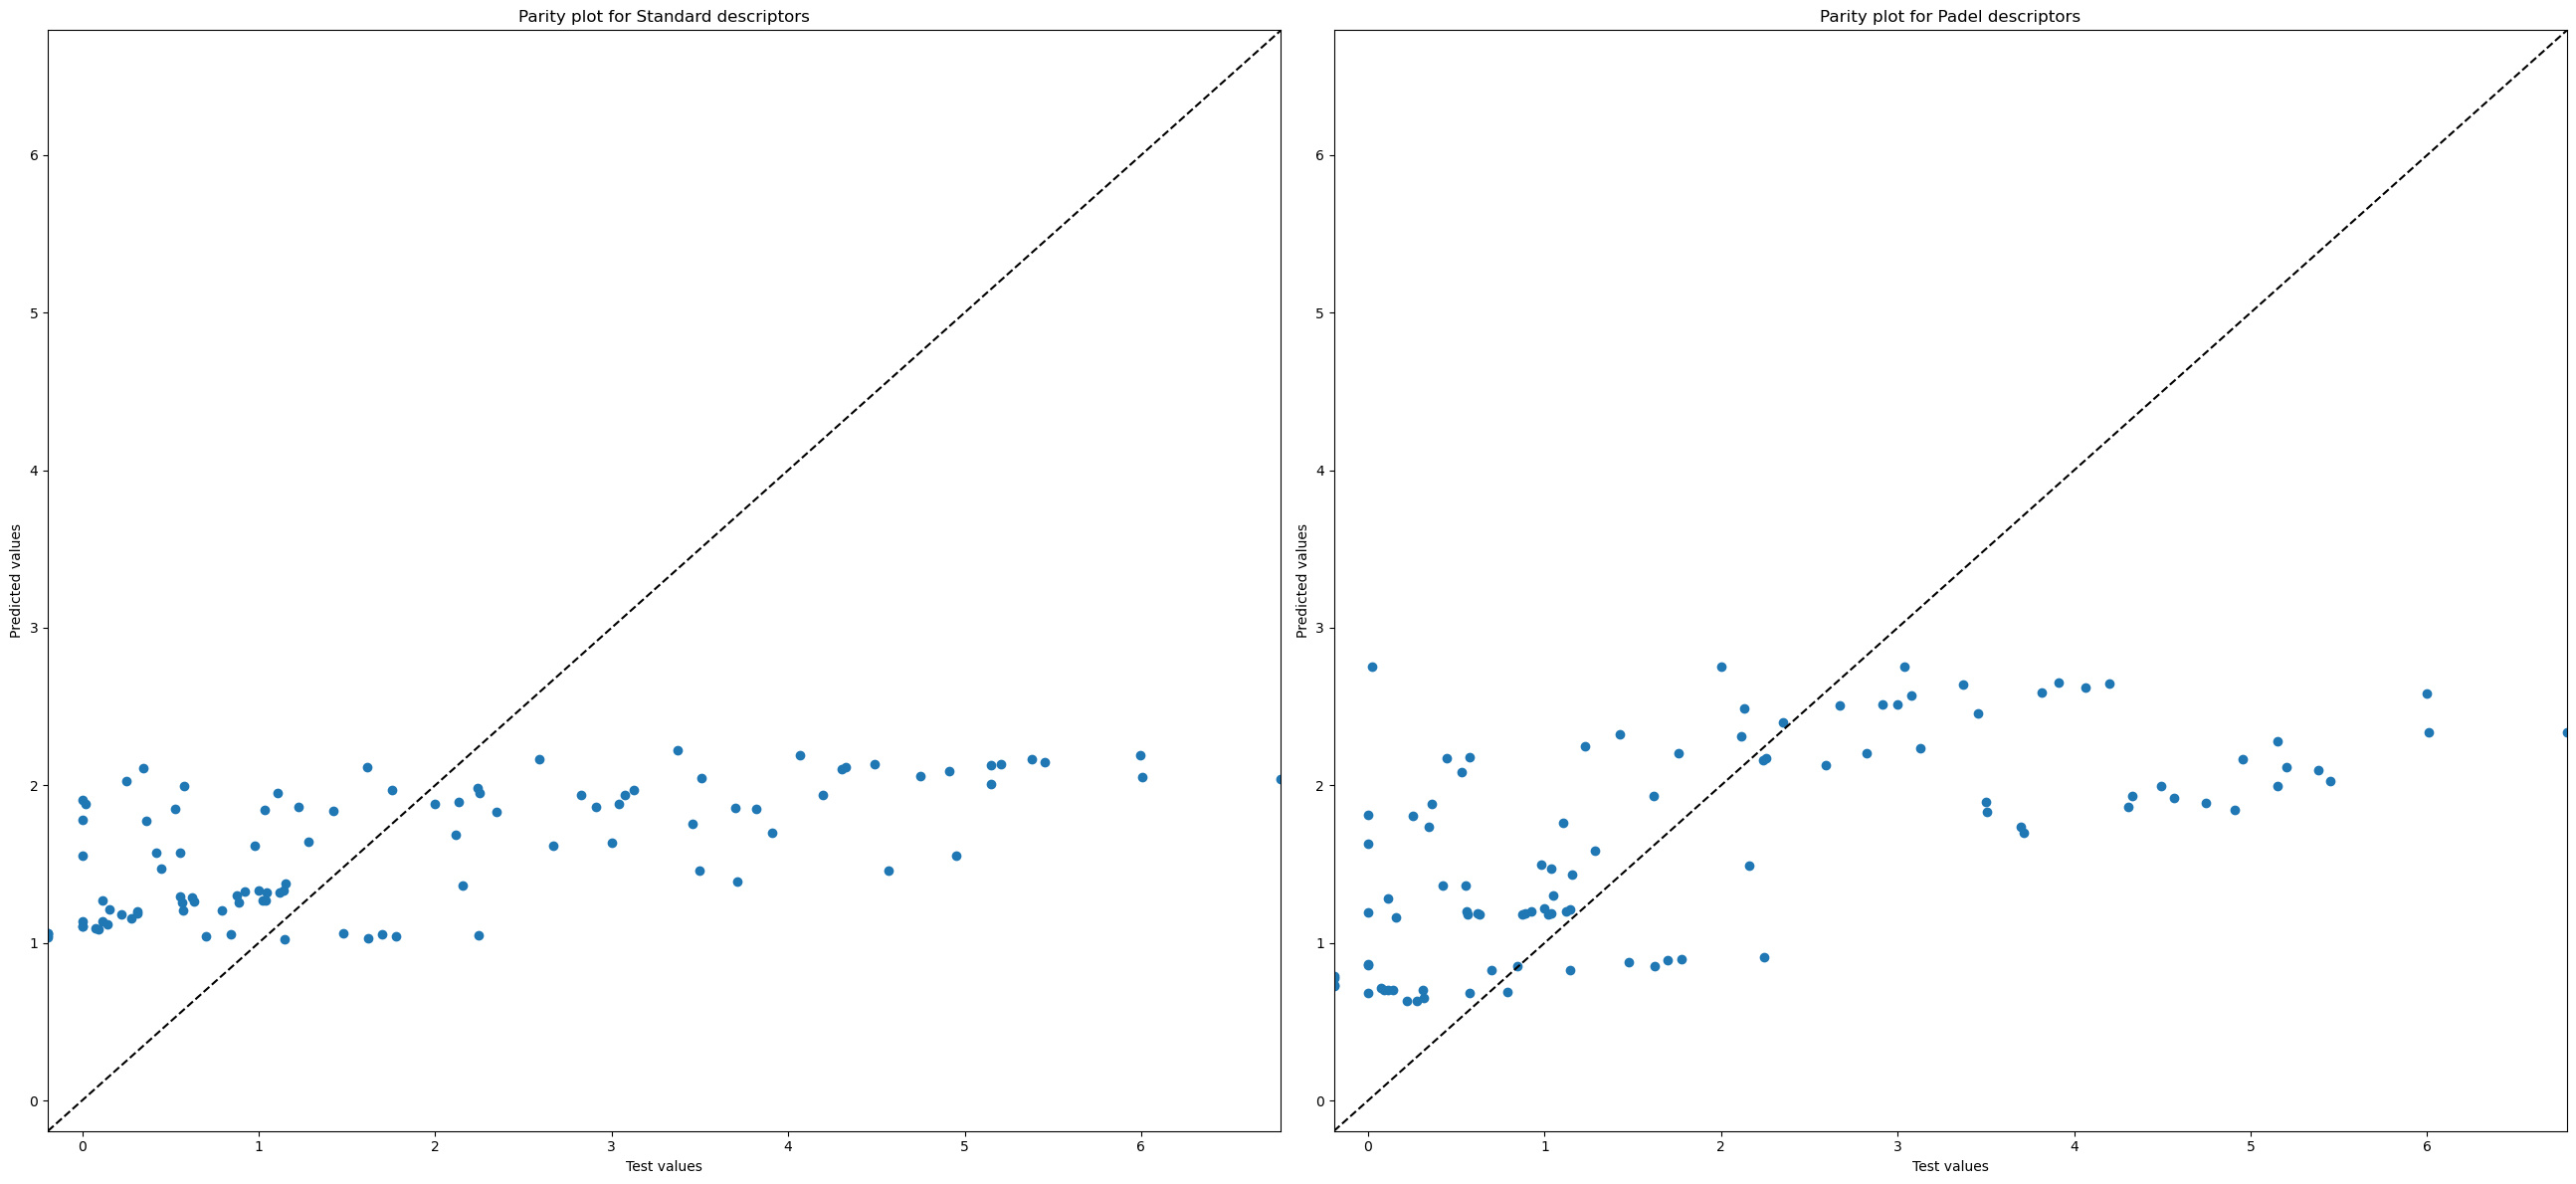

In [436]:
calculate_to_score(pipe, estimator_name = 'Random Forest', param_grid =  space,
                   descriptors_dict=descriptors_dict,
                   target=target,type = 'Full')
               

100%|██████████| 50/50 [06:37<00:00,  7.95s/trial, best loss: 1.2305945896133834]
{'criterion': 0, 'max_depth': 11, 'max_features': 0, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 71, 'threshold': 0.2924014466511377}
Loss is 1.2305945896133834
Standard deviation is 0.20372642313355377
100%|██████████| 50/50 [15:11<00:00, 18.22s/trial, best loss: 1.16652757577414]  
{'criterion': 2, 'max_depth': 12, 'max_features': 0, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 92, 'threshold': 0.15845092832551227}
Loss is 1.16652757577414
Standard deviation is 0.2124753625154034


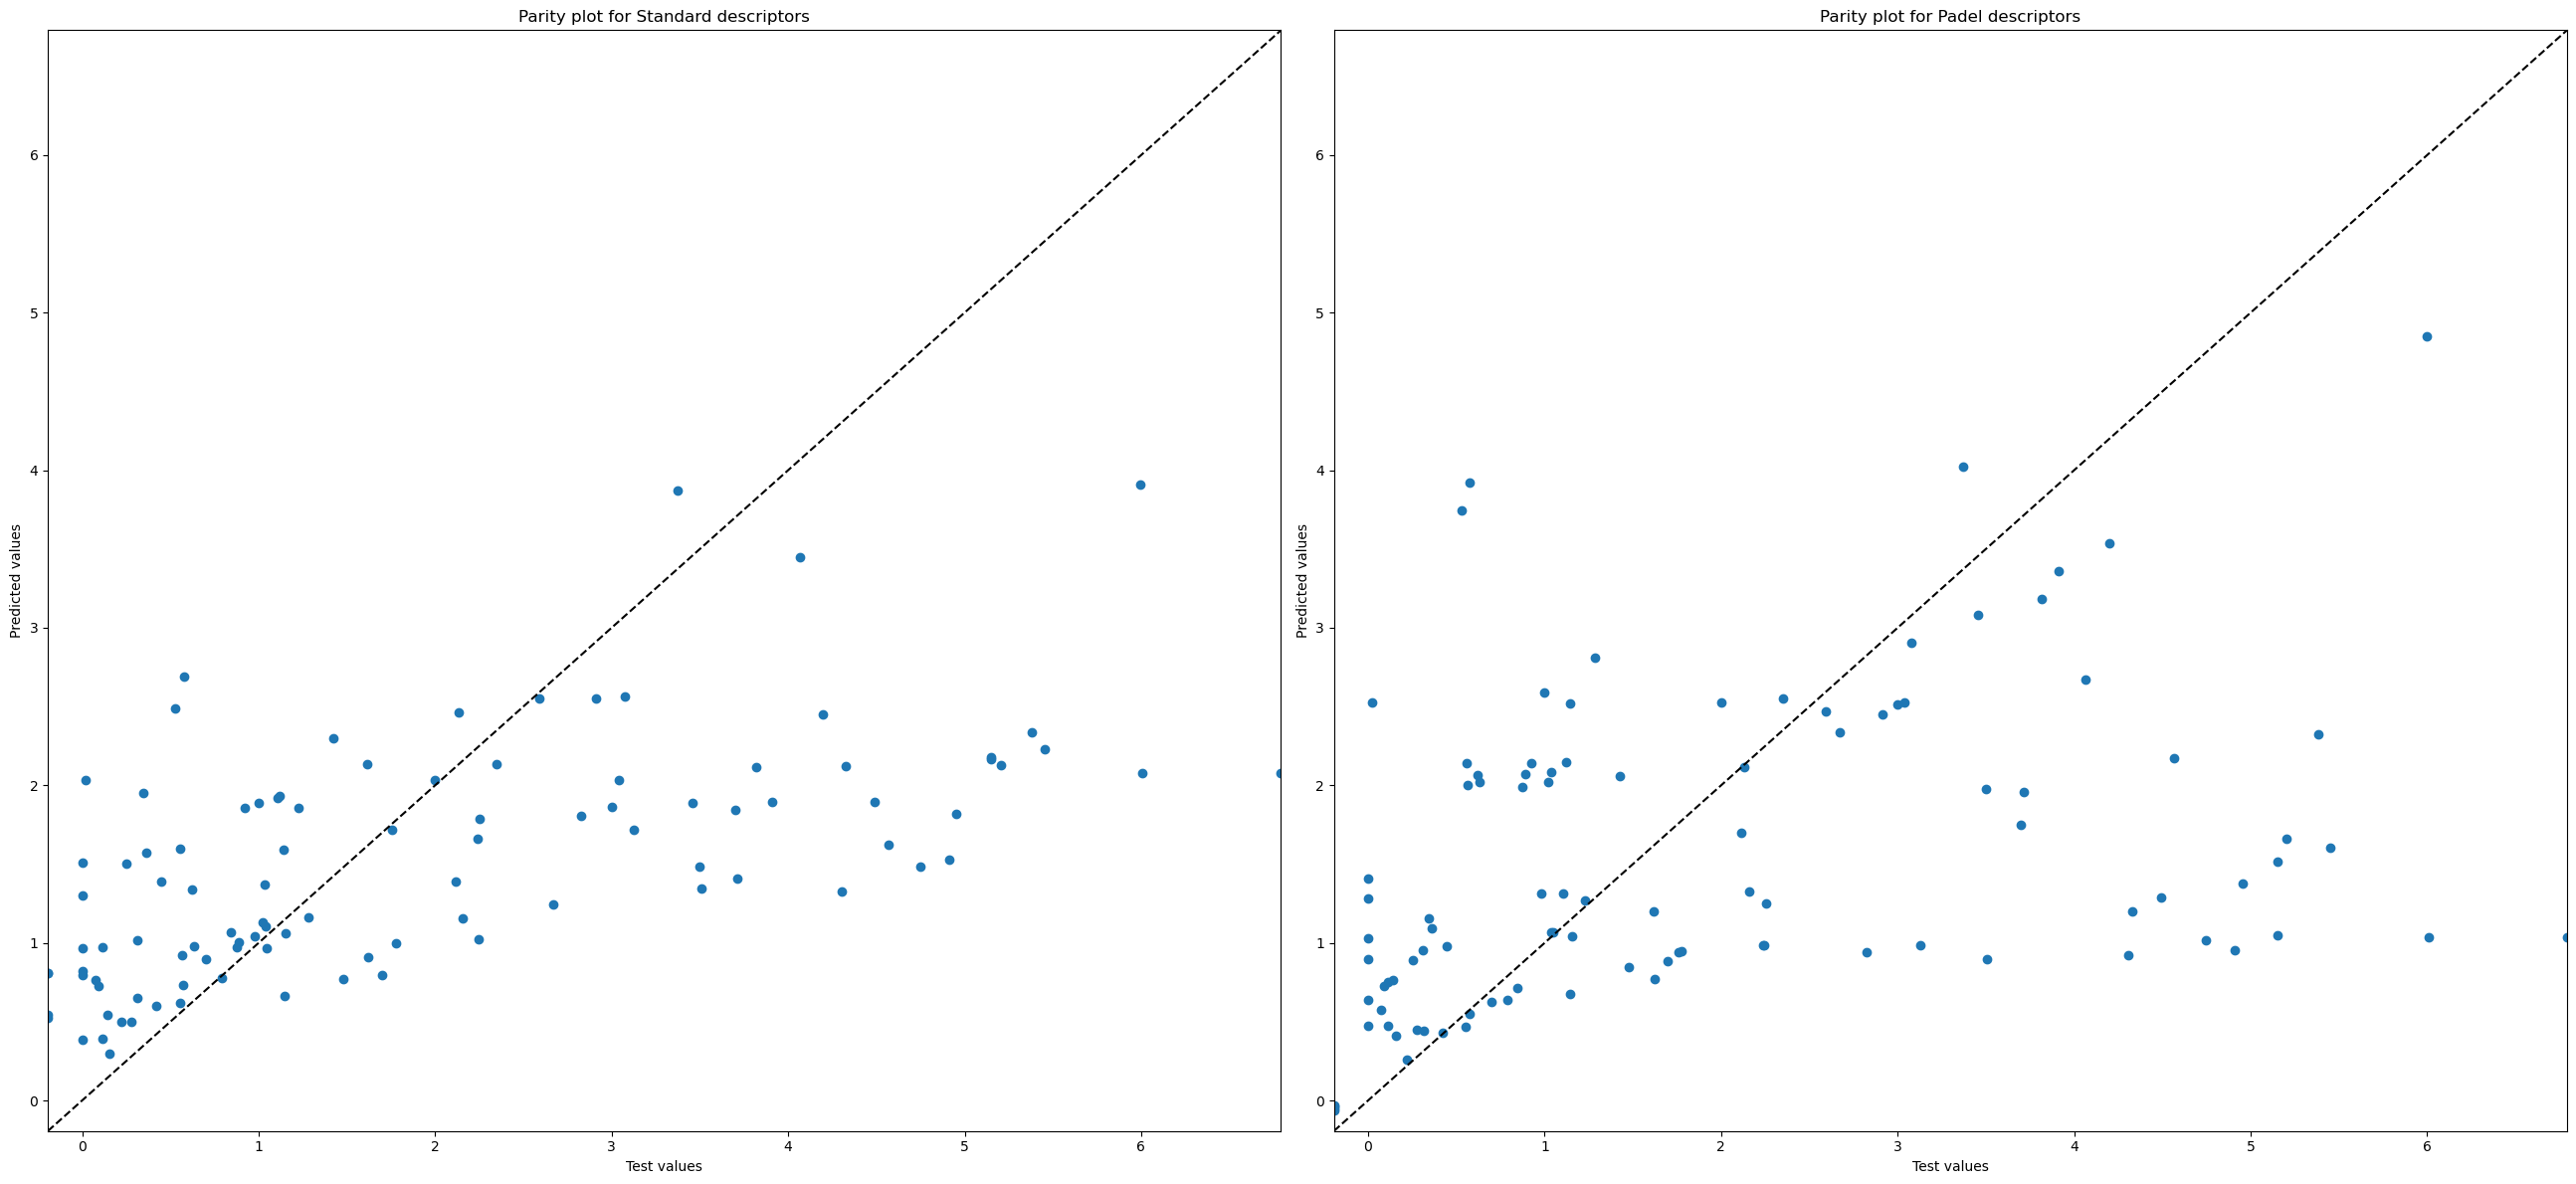

In [437]:
calculate_to_score(pipe, estimator_name = 'Random Forest', param_grid =  space,
                   descriptors_dict=descriptors_dict_pca,
                   target=target,                   type = 'PCA')


**SVM**

In [438]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                 ('svc', SVR())])

In [439]:
space = {'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
         #'model_sel__estimator__alpha':hp.loguniform(label = 'alpha', low = -1, high =2),
    'svc__C':hp.loguniform('C', -3*np.log(10), 2*np.log(10)),
         'svc__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svc__degree':hp.choice('degree', [2,3]),
         'svc__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svc__coef0':hp.loguniform('coef0', -3*np.log(10), 0*np.log(10))}

100%|██████████| 50/50 [02:50<00:00,  3.40s/trial, best loss: 1.5091122659982916]
{'C': 0.0011043871341954428, 'coef0': 0.9296013282722508, 'degree': 1, 'gamma': 0, 'kernel': 2, 'threshold': 0.03765754428344903}
Loss is 1.5091122659982916
Standard deviation is 0.24462791910986464
100%|██████████| 50/50 [01:17<00:00,  1.56s/trial, best loss: 1.5557311000974985]
{'C': 0.16100249246654977, 'coef0': 0.020230657418672218, 'degree': 1, 'gamma': 1, 'kernel': 3, 'threshold': 0.035582331552916346}
Loss is 1.5557311000974985
Standard deviation is 0.26033792162758185


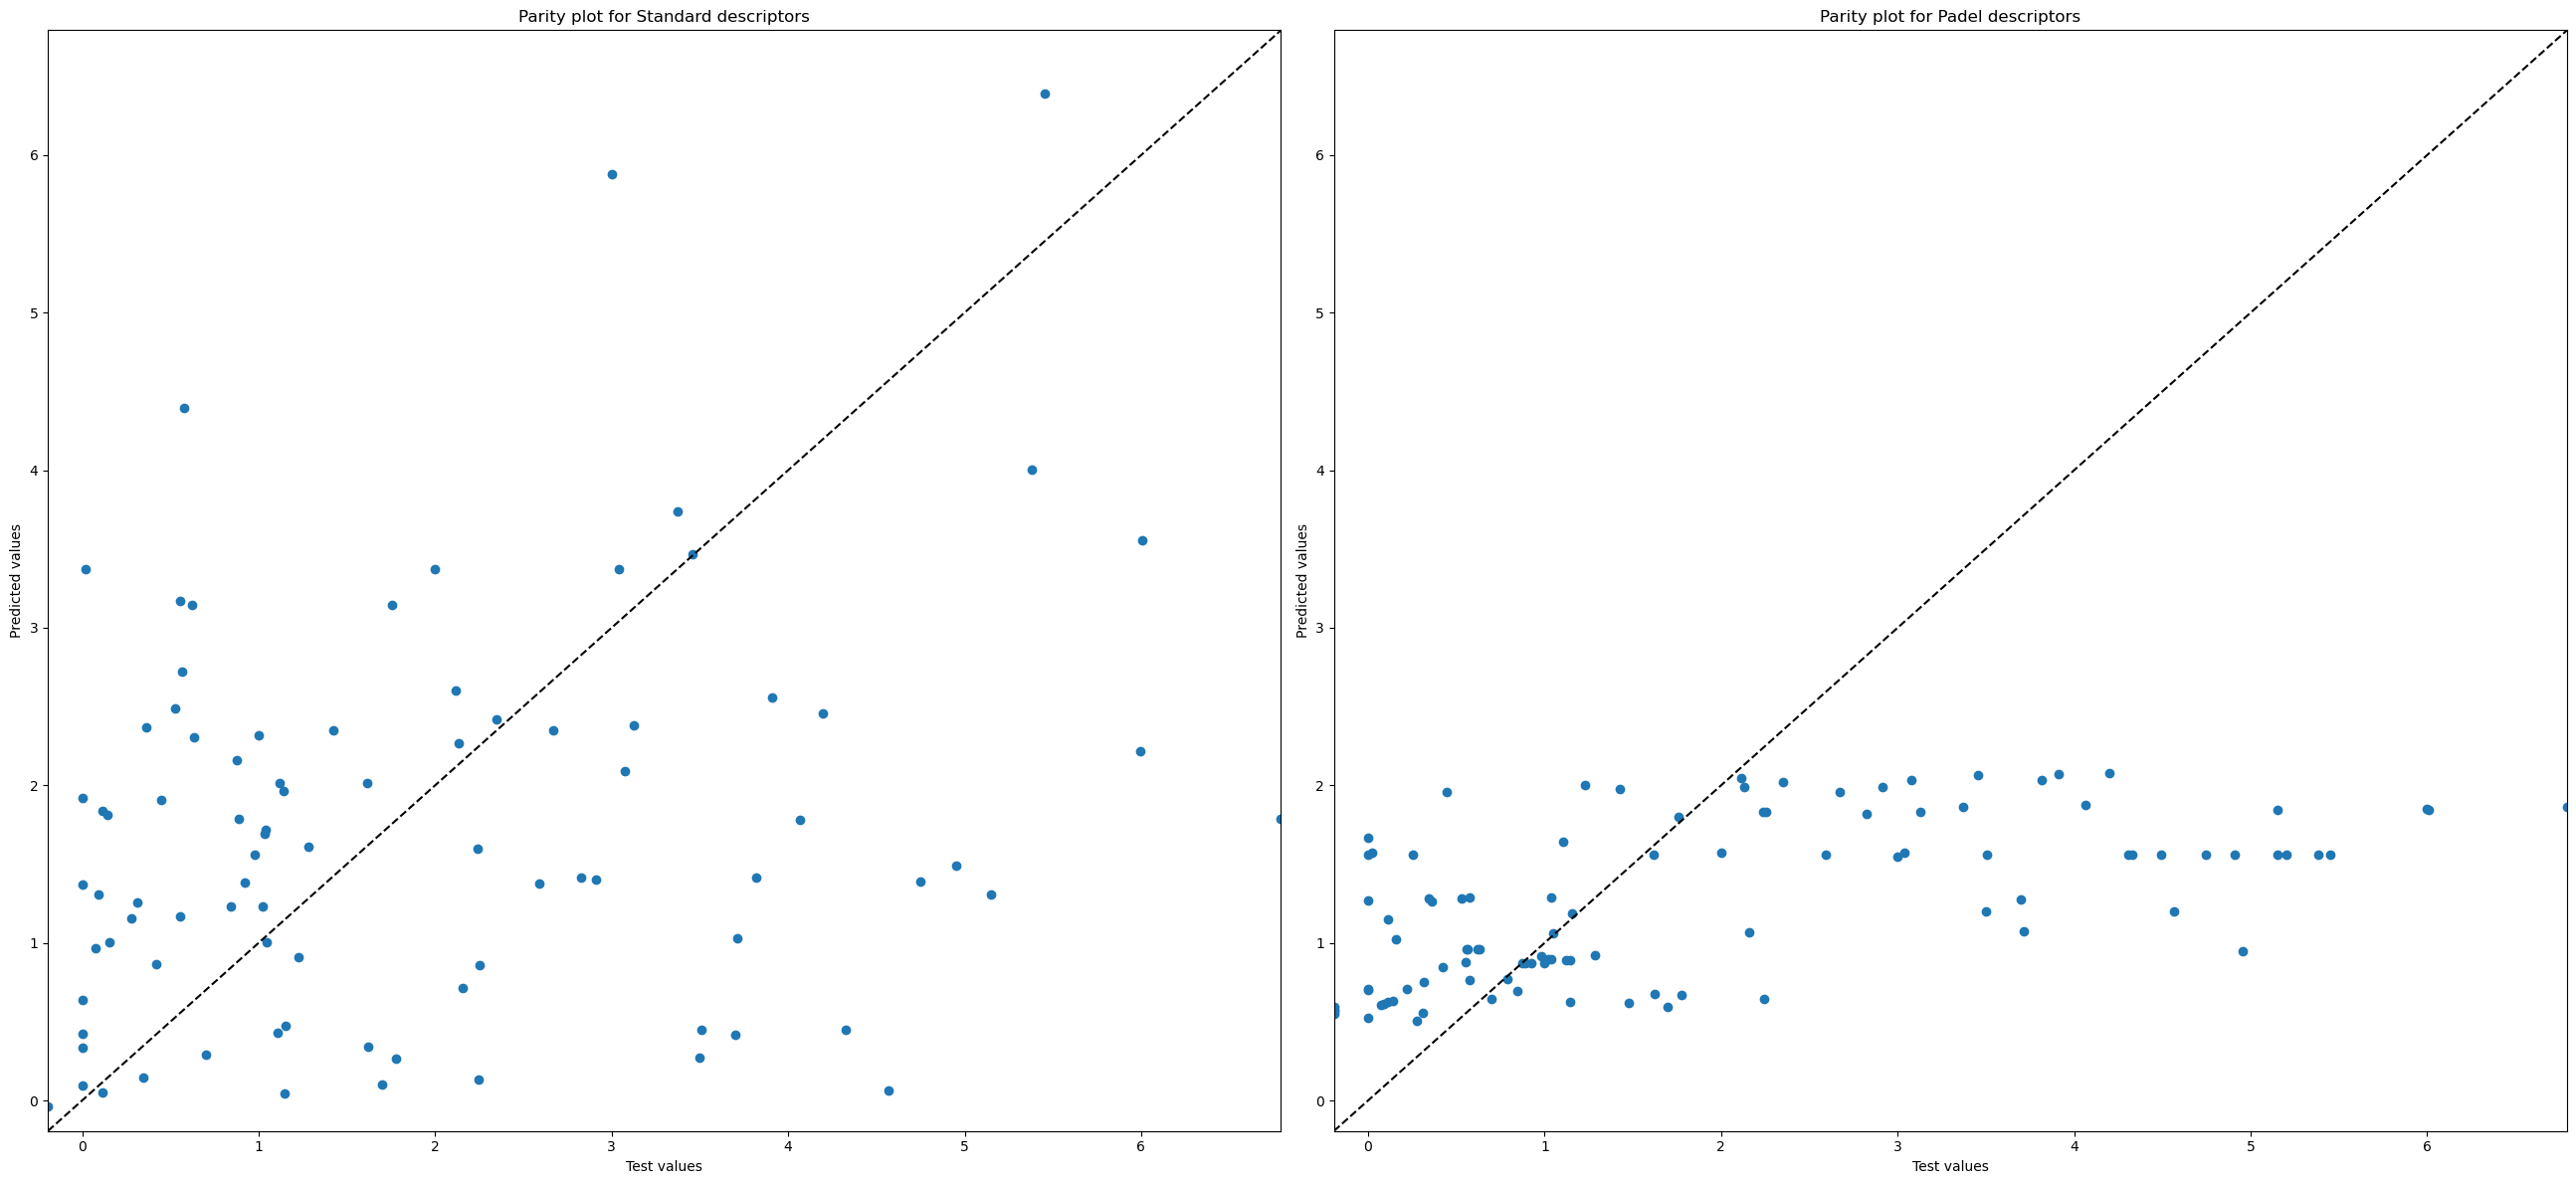

In [440]:
calculate_to_score(pipe, estimator_name = 'SVC', param_grid = space, descriptors_dict=descriptors_dict, target = target, type = 'Full')
                                                                


100%|██████████| 50/50 [02:05<00:00,  2.51s/trial, best loss: 1.559567952885708] 
{'C': 0.9575931262964481, 'coef0': 0.6119100069067273, 'degree': 0, 'gamma': 1, 'kernel': 0, 'threshold': 0.3318520736762998}
Loss is 1.559567952885708
Standard deviation is 0.2843054777222562
100%|██████████| 50/50 [01:22<00:00,  1.64s/trial, best loss: 1.5032760896309654]
{'C': 0.001493189622511552, 'coef0': 0.01055959205207806, 'degree': 1, 'gamma': 0, 'kernel': 2, 'threshold': 0.11124404670441614}
Loss is 1.5032760896309654
Standard deviation is 0.23252696782315205


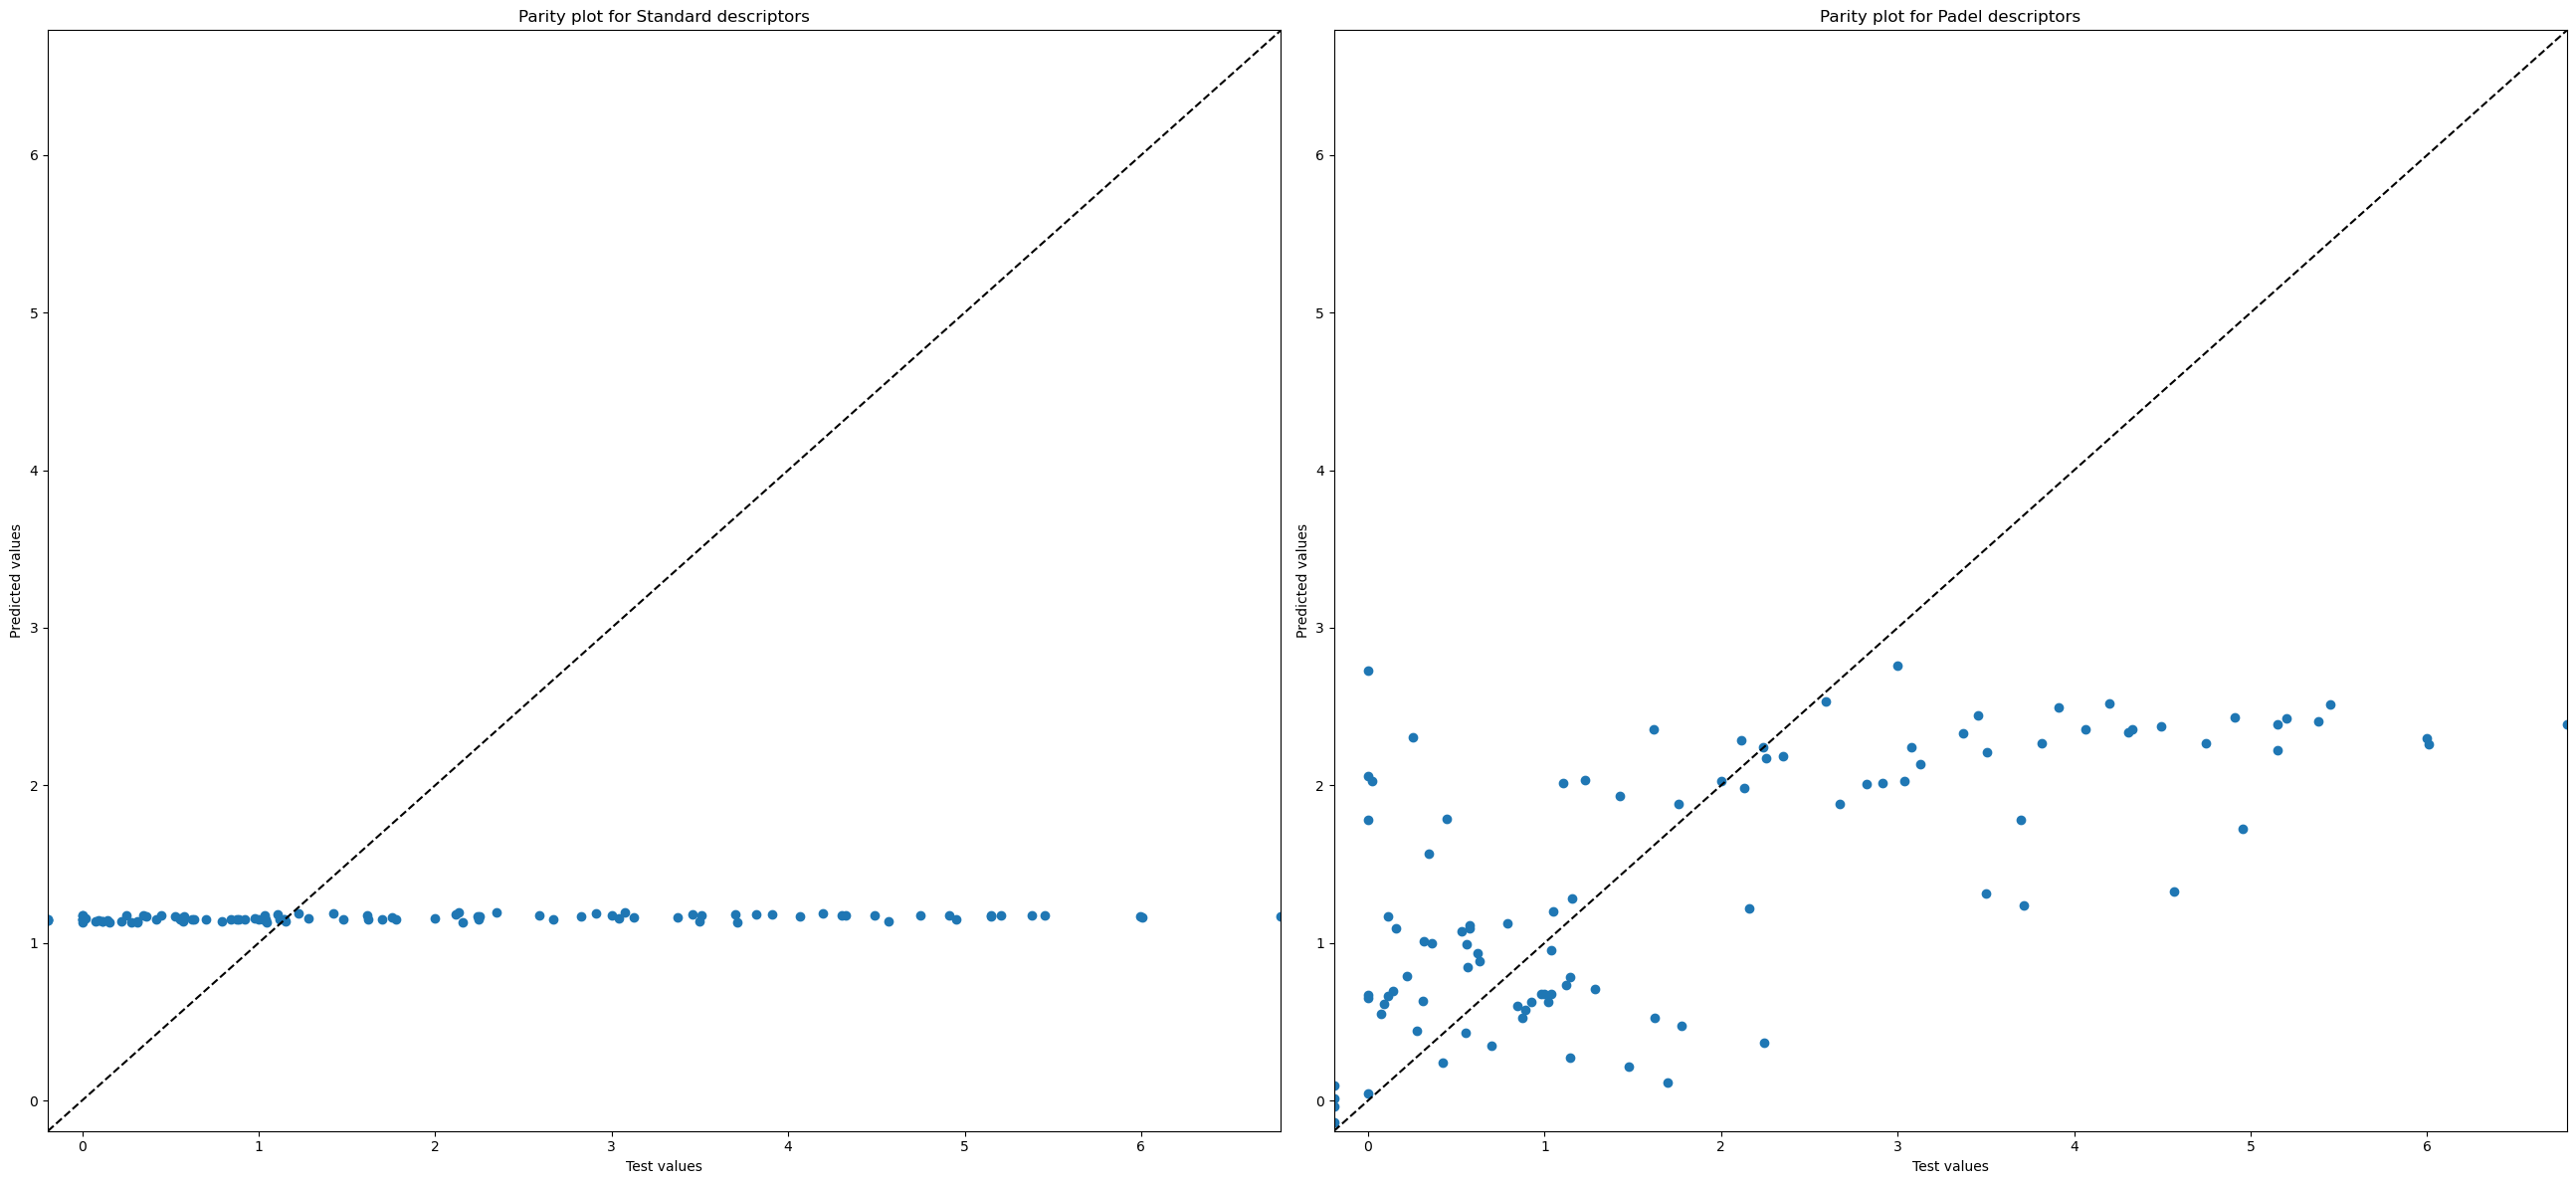

In [441]:
calculate_to_score(pipe, estimator_name = 'SVC', param_grid = space, descriptors_dict=descriptors_dict_pca, target = target, type = 'PCA')


**KNearestneighbors**

In [442]:
pipe = Pipeline([('varsel',VarianceThreshold()),
                 ('scaler',StandardScaler()),
                 ('kneighborsregressor', KNeighborsRegressor())])

In [443]:
space = {'varsel__threshold':hp.uniform(label = 'threshold', low = 0, high  = 0.4),
    'kneighborsregressor__n_neighbors':hp.randint('n_neighbors',1, 10),
         'kneighborsregressor__weights':hp.choice('weights', ['uniform', 'distance']),
         'kneighborsregressor__metric':hp.choice('metric', ['minkowski', 'chebyshev', 'cosine', 'euclidean'])}


100%|██████████| 50/50 [00:49<00:00,  1.00trial/s, best loss: 1.4732296670480787]
{'metric': 0, 'n_neighbors': 8, 'threshold': 0.09579533702148071, 'weights': 0}
Loss is 1.4732296670480787
Standard deviation is 0.27046289783211513
100%|██████████| 50/50 [00:49<00:00,  1.01trial/s, best loss: 1.5241007288099275]
{'metric': 2, 'n_neighbors': 2, 'threshold': 0.02532495888779982, 'weights': 0}
Loss is 1.5241007288099275
Standard deviation is 0.4525095814677126


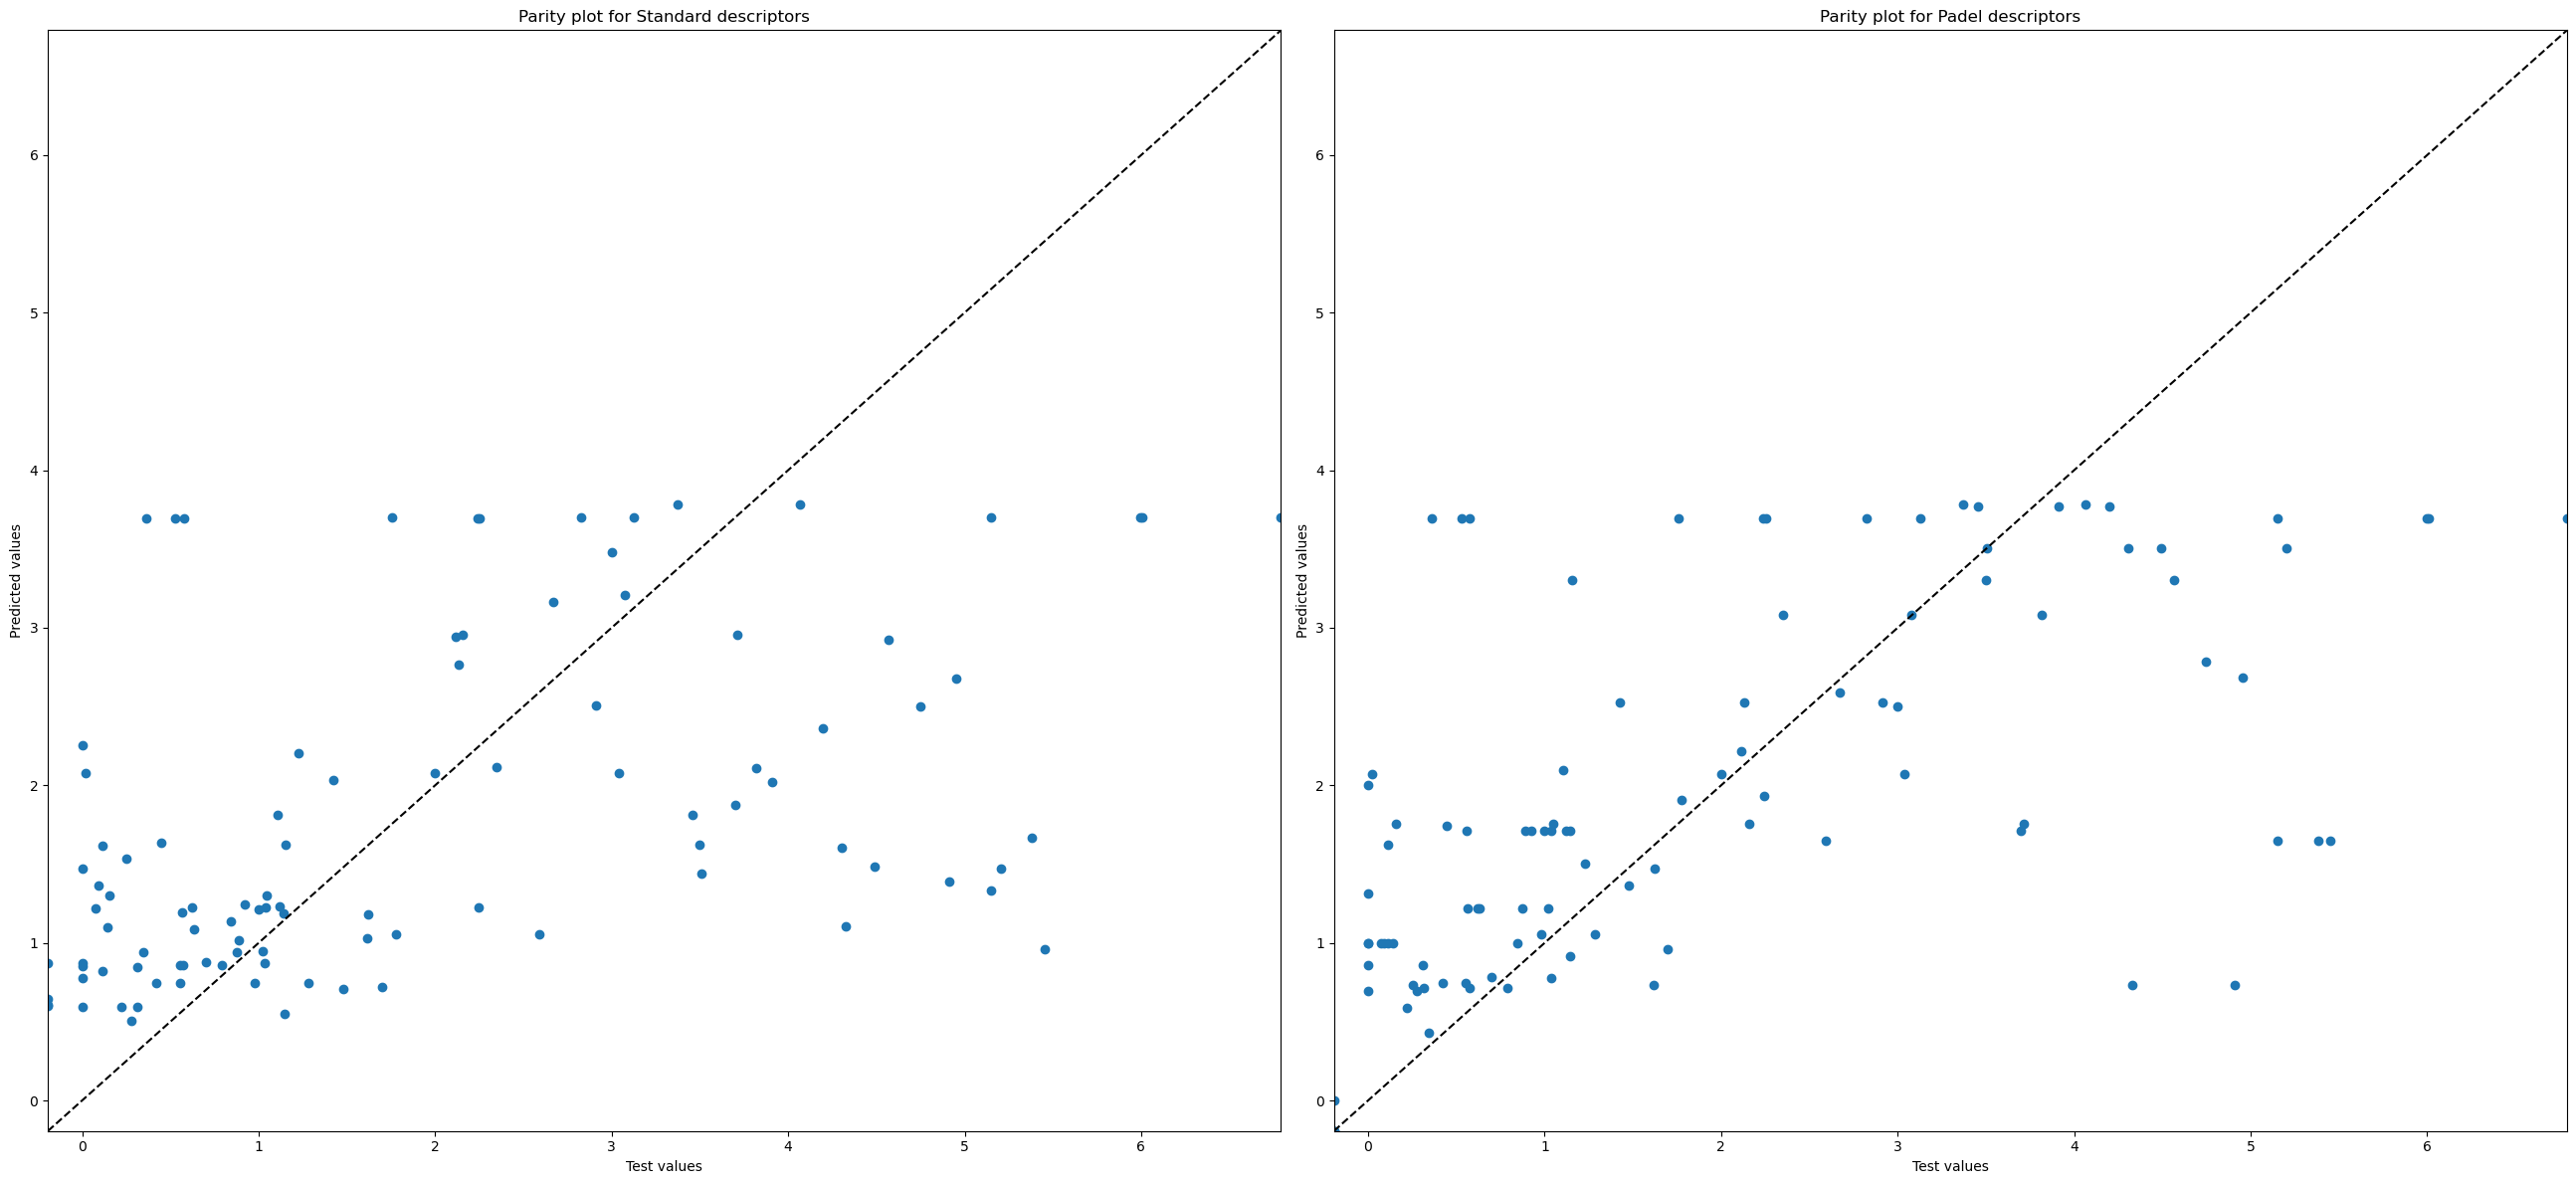

In [444]:
calculate_to_score(pipe, estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict, target=target, type = 'Full')

100%|██████████| 50/50 [00:50<00:00,  1.01s/trial, best loss: 1.4889565340184698]
{'metric': 3, 'n_neighbors': 9, 'threshold': 0.09539497151406282, 'weights': 1}
Loss is 1.4889565340184698
Standard deviation is 0.2480514556075456
100%|██████████| 50/50 [00:49<00:00,  1.01trial/s, best loss: 1.5602759467448784]
{'metric': 2, 'n_neighbors': 9, 'threshold': 0.045236190544233126, 'weights': 0}
Loss is 1.5602759467448784
Standard deviation is 0.2988420160100749


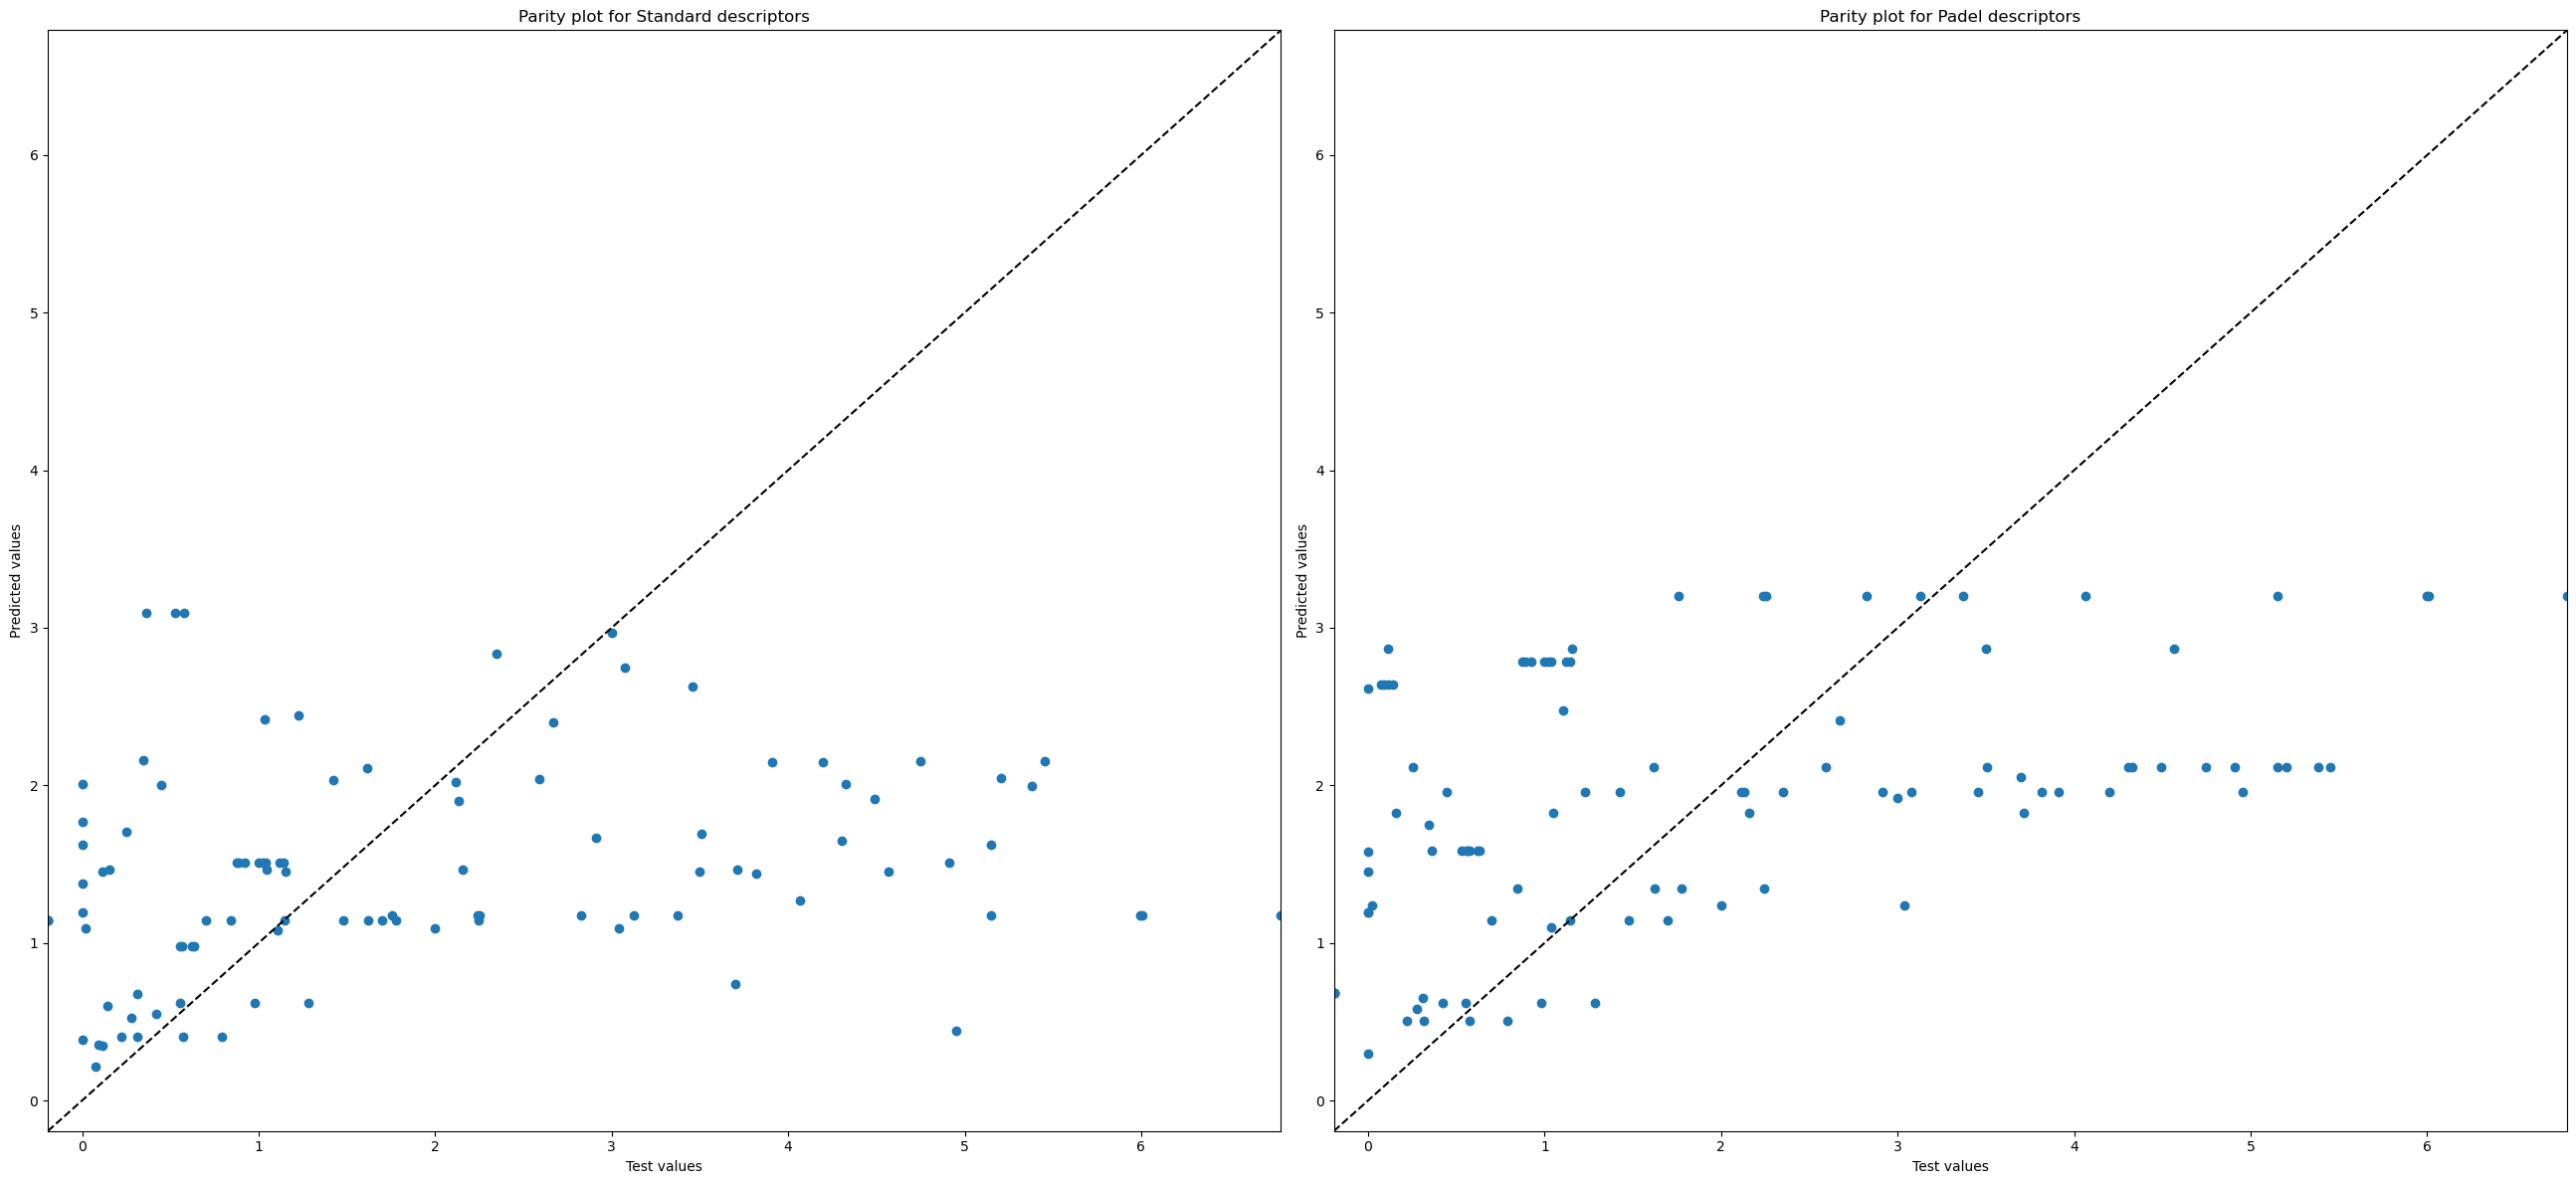

In [445]:
calculate_to_score(pipe, estimator_name='KMeans', param_grid=space, 
                   descriptors_dict=descriptors_dict_pca, target=target, type = 'PCA')

Let's save results into pickle file and show the final scores model in readable format

In [446]:
pd.DataFrame(scores)

,Descriptors,Estimator,Full or PCA,RMSE_CV,Stddev_RMSE_CV,R2_CV,MAE_CV,RMSE_test,MAE_test,R2_test
0,Standard,Lasso regression,Full,1.511117,0.225724,0.072334,1.217678,1.806835,1.478978,-0.019387
1,Padel,Lasso regression,Full,1.520138,0.228962,0.061708,1.240250,1.550664,1.246127,0.249177
2,Standard,Lasso Regression,PCA,1.484756,0.209897,0.103312,1.186530,1.778499,1.434387,0.012336
3,Padel,Lasso Regression,PCA,1.508774,0.227642,0.073755,1.231279,1.806835,1.478978,-0.019387
4,Standard,Random Forest,Full,1.229405,0.230985,0.374009,0.983398,1.598676,1.269974,0.201963
5,Padel,Random Forest,Full,1.178250,0.213182,0.426903,0.922352,1.481440,1.103238,0.314717
6,Standard,Random Forest,PCA,1.230595,0.203726,0.373695,0.992682,1.516736,1.121758,0.281674
7,Padel,Random Forest,PCA,1.166528,0.212475,0.441276,0.908199,1.735825,1.216737,0.059164
8,Standard,SVC,Full,1.509112,0.244628,0.075393,1.112733,2.329170,1.671496,-0.693964
9,Padel,SVC,Full,1.555731,0.260338,0.023085,1.153392,1.679523,1.195314,0.119207


In [447]:
with open('score_regression_structure.pickle', 'wb') as output:
    pickle.dump(scores, output)